# dataset

http://archive.ics.uci.edu/ UCI Adult : classify people using demographical data - whether they earn more than $50,000 per year or not.  
https://www.kaggle.com/datasets/sagnikpatra/uci-adult-census-data-dataset

- Age – continuous feature  
- Workclass – continuous feature
- fnlwgt – final weight of object, continuous feature
- Education – categorical feature
- Education_Num – number of years of education, continuous feature
- Martial_Status – categorical feature
- Occupation – categorical feature
- Relationship – categorical feature
- Race – categorical feature
- Sex – categorical feature
- Capital_Gain – continuous feature
- Capital_Loss – continuous feature
- Hours_per_week – continuous feature
- Country – categorical feature
- Target – earnings level, categorical (binary) feature.

# 1. import data


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

In [3]:
input_file = 'labor_risk_profiling_dataset\\adult.csv'
df=pd.read_csv(input_file)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# 2. Analisi Esplorativa (EDA)
cosa faccio per eda correlazione? conteggio null? come scelgo le classi?

In [6]:
df_1=df.copy()

In [7]:
df_1.replace('?', np.nan, inplace=True)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [8]:
df_1.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [9]:
df_1.shape

(32561, 15)

## Missing analysis with matrix

<Axes: >

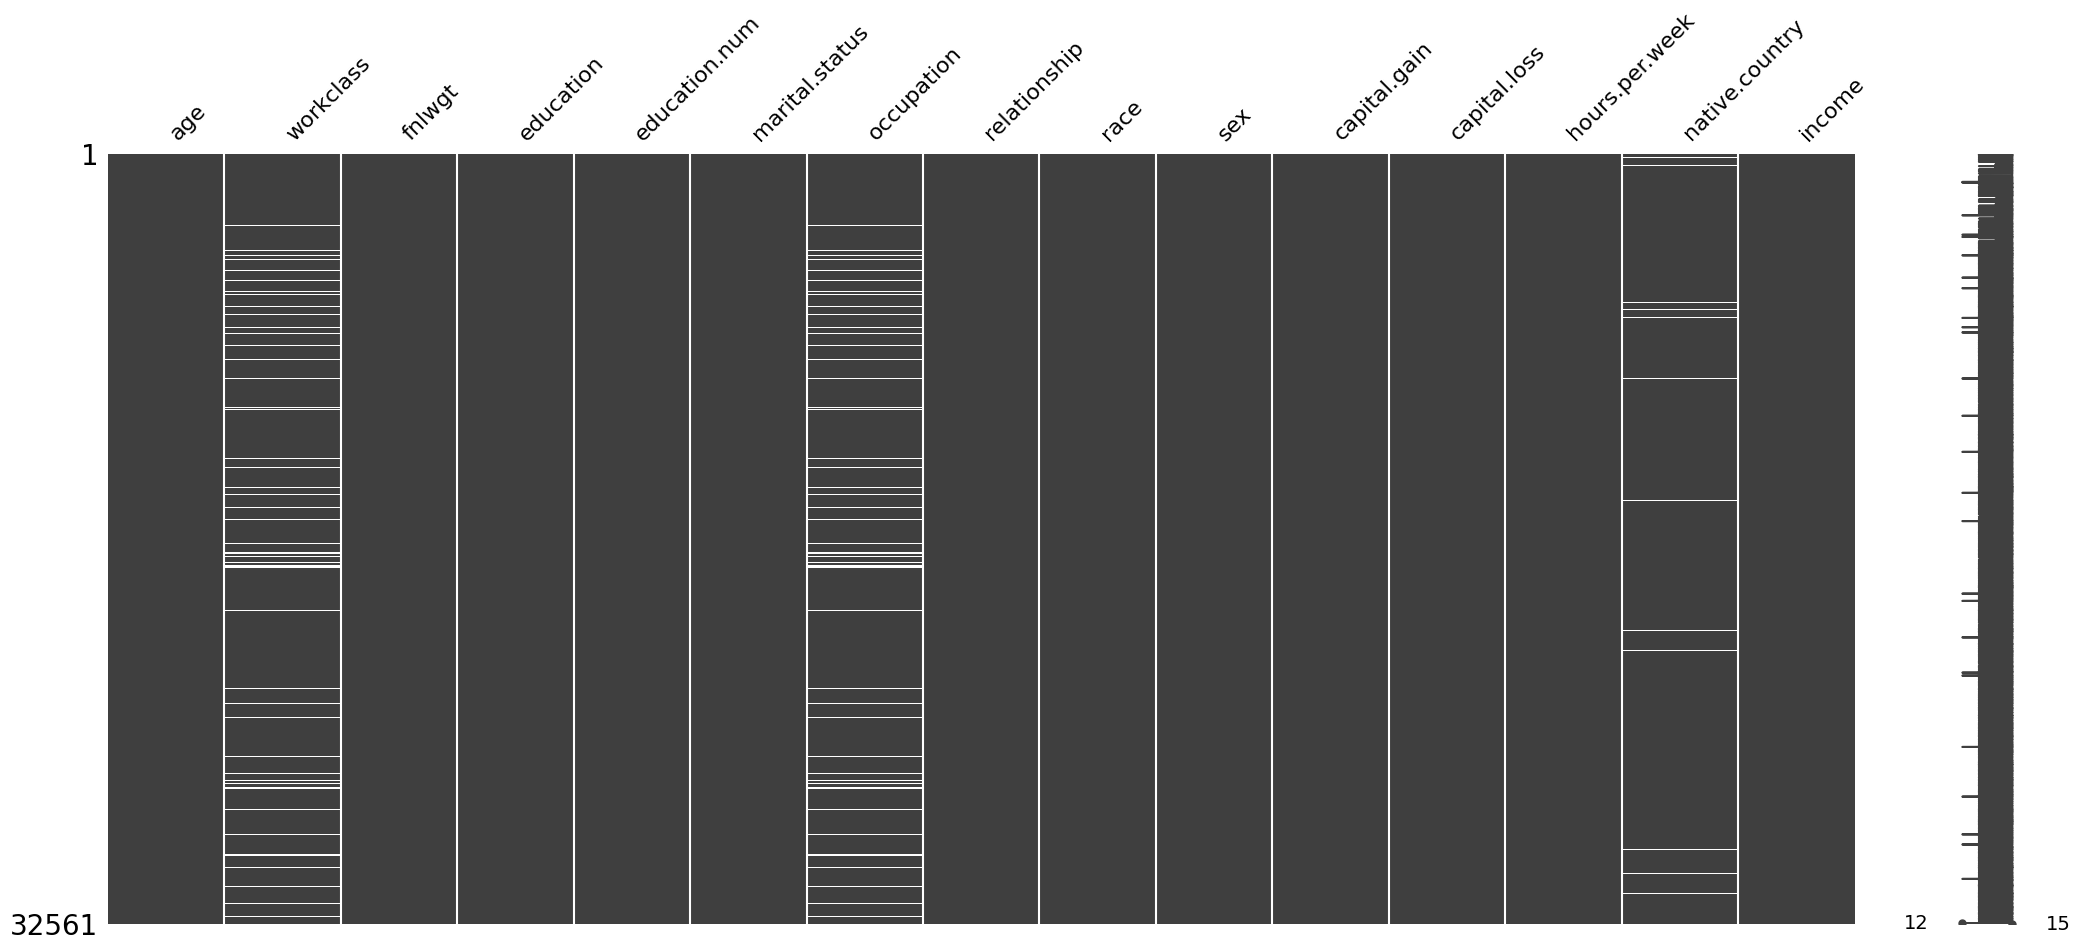

In [10]:
import missingno as msno
msno.matrix(df_1)

In [11]:
df_1.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='str')

## Plot for variables analysis

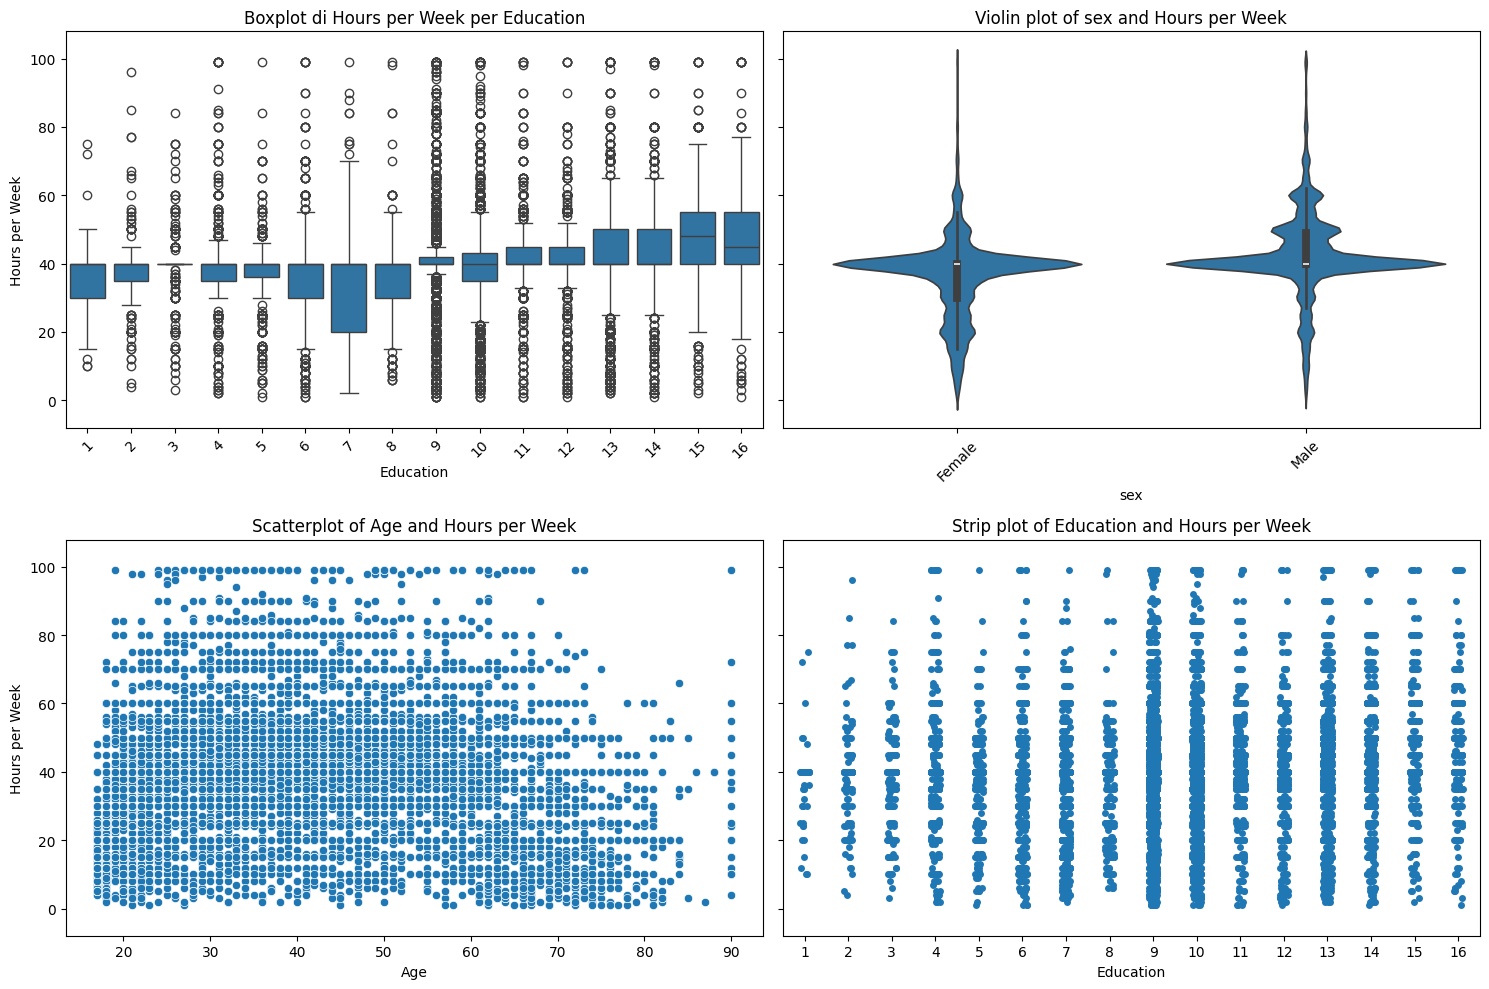

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig,axes=plt.subplots(2,2,figsize=(15,10), sharey=True)

#primo grafico
sns.boxplot(x='education.num', y='hours.per.week',data=df_1, ax=axes[0,0])
axes[0,0].set_title('Boxplot di Hours per Week per Education')
axes[0,0].set_xlabel('Education')
axes[0,0].set_ylabel('Hours per Week')
axes[0,0].tick_params(axis='x', rotation=45)

#secondo grafico
sns.violinplot(x='sex', y='hours.per.week',data=df_1, ax=axes[0,1])
axes[0,1].set_title('Violin plot of sex and Hours per Week')
axes[0,1].set_xlabel('sex')
axes[0,1].set_ylabel('Hours per Week')
axes[0,1].tick_params(axis='x', rotation=45)

#terzo grafico
sns.scatterplot(x='age', y='hours.per.week',data=df_1, ax=axes[1,0])
axes[1,0].set_title('Scatterplot of Age and Hours per Week')    
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Hours per Week')

#quarto grafico
sns.stripplot(x='education.num', y='hours.per.week',data=df_1, jitter=True, ax=axes[1,1])
axes[1,1].set_title('Strip plot of Education and Hours per Week')
axes[1,1].set_xlabel('Education')
axes[1,1].set_ylabel('Hours per Week')

plt.tight_layout()

## Income difference graph by age and sex

In [13]:
# definizione delle fasce d'età
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['0-25', '26-35', '36-45', '46-55', '56-65', '66+']
df_1['age_bins'] = pd.cut(df_1['age'], bins=bins, labels=labels)
# Trasforma la colonna in categoria ordinata
df_1['age_bins'] = pd.Categorical(df_1['age_bins'], categories=labels, ordered=True)

In [14]:
df_1['is_high_income']=df_1['income'].apply( lambda x: 0 if x=='<=50K' else 1)

<Axes: xlabel='sex', ylabel='age_bins'>

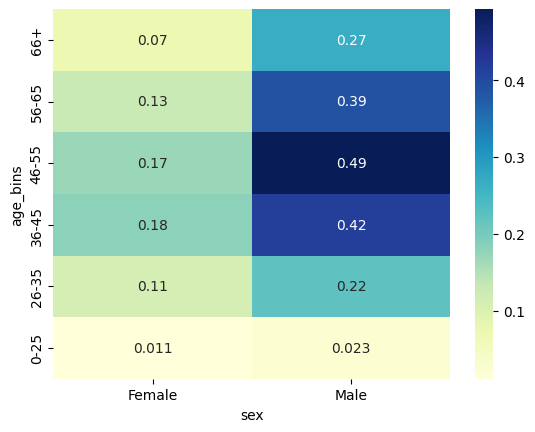

In [15]:
# mean number of people with income > 50K for sex and age_bins
pivot_income = df_1.pivot_table(values='is_high_income', index='age_bins', columns='sex', aggfunc='mean')
sns.heatmap(pivot_income.iloc[::-1], annot=True, cmap='YlGnBu')

## Education and income

In [16]:
pivot_education_income=pd.pivot_table(values='is_high_income', index='education.num', columns='sex', aggfunc='mean', data=df_1)
pivot_education_income

sex,Female,Male
education.num,,
1,0.000000,0.000000
2,0.000000,0.049180
3,0.023810,0.056225
4,0.006250,0.080247
5,0.034722,0.059459
6,0.010169,0.092476
7,0.018519,0.069987
8,0.027778,0.100346
9,0.066667,0.203769


<Axes: xlabel='sex', ylabel='education.num'>

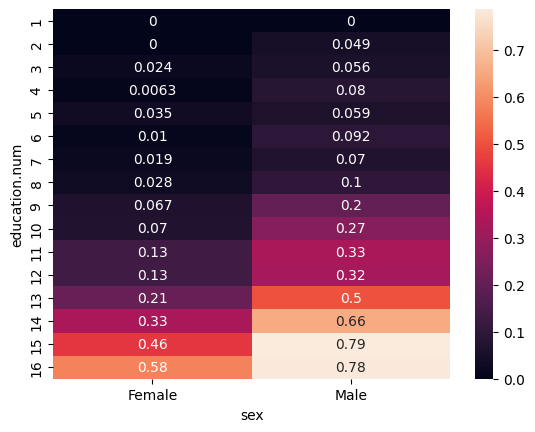

In [17]:
sns.heatmap(pivot_education_income,annot=True)

## Comparison between probability of low_income between male and female by age 

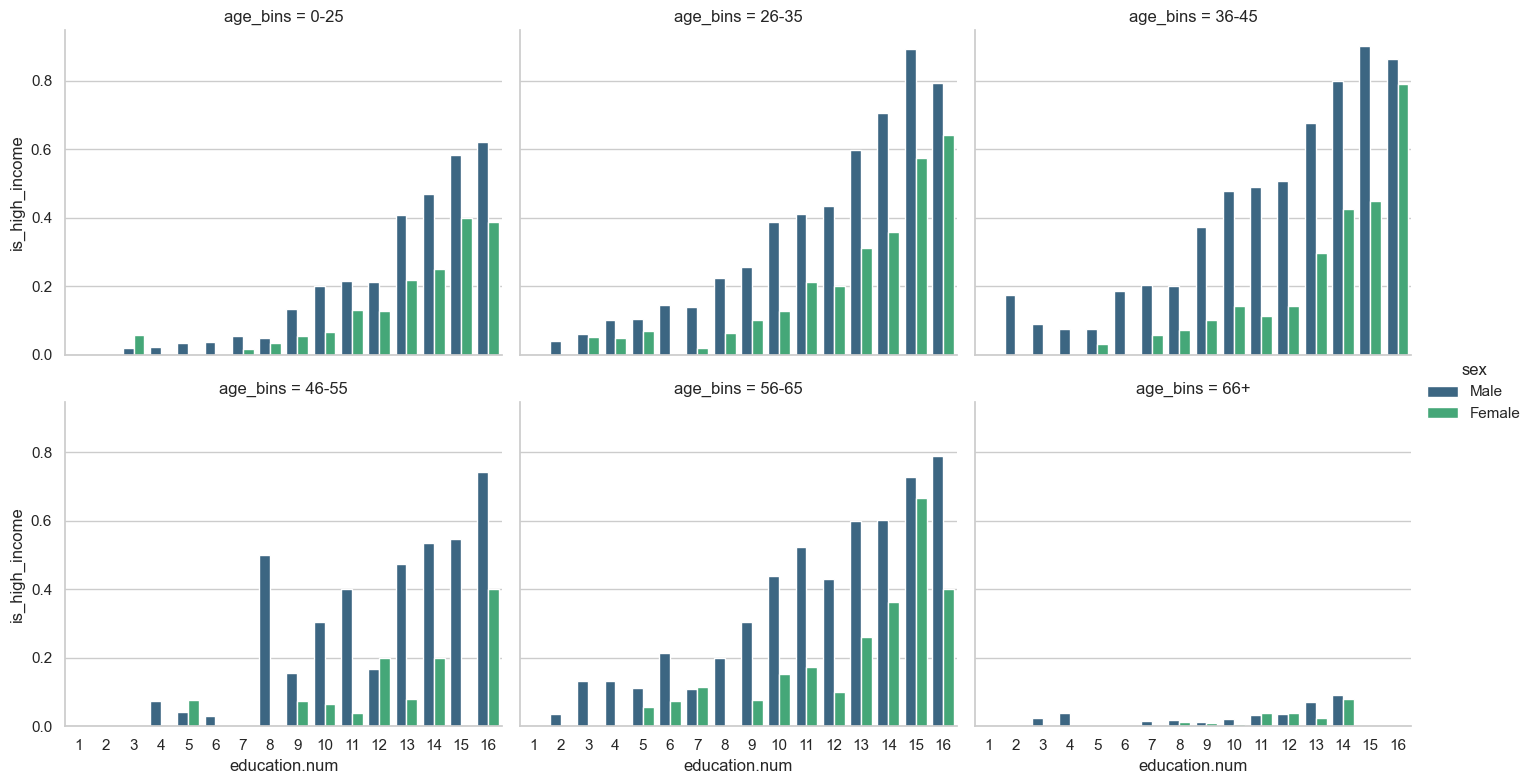

In [18]:
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_1, 
    kind="bar",
    x="education.num", 
    y="is_high_income", 
    hue="sex",
    col="age_bins", 
    errorbar=None,
    col_wrap=3,          # Numero di grafici per riga
    palette="viridis",    # Schema colori
    height=4, 
    aspect=1.2
)

## Subplot of all numerical variables

In [20]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             32561 non-null  int64   
 1   workclass       30725 non-null  str     
 2   fnlwgt          32561 non-null  int64   
 3   education       32561 non-null  str     
 4   education.num   32561 non-null  int64   
 5   marital.status  32561 non-null  str     
 6   occupation      30718 non-null  str     
 7   relationship    32561 non-null  str     
 8   race            32561 non-null  str     
 9   sex             32561 non-null  str     
 10  capital.gain    32561 non-null  int64   
 11  capital.loss    32561 non-null  int64   
 12  hours.per.week  32561 non-null  int64   
 13  native.country  31978 non-null  str     
 14  income          32561 non-null  str     
 15  age_bins        32561 non-null  category
 16  is_high_income  32561 non-null  int64   
dtypes: category(1), int64(7

In [21]:
# individuo le variabili numeriche e categoriche
def identify_variable_types(df):
    numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
    return numeric_features, categorical_features

In [23]:
result=identify_variable_types(df_1)

C:\Users\marco\AppData\Local\Temp\ipykernel_10372\3651389566.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [30]:
import math

In [32]:
def plot_outliers(df, lista):
        # Calcoliamo quante righe servono per avere 3 colonne al massimo
    n_cols = 3
    n_rows = math.ceil(len(lista) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() # Lo rendiamo 1D per gestirlo facilmente

    for i, col in enumerate(lista):
        sns.boxplot(data=df, x=col, ax=axes[i], color='skyblue', fliersize=5)
        axes[i].set_title(f'Focus Outlier: {col}', fontsize=14)
        axes[i].grid(True, linestyle='--', alpha=0.6)

    # Nascondiamo i grafici vuoti se la lista non riempie l'ultima riga
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

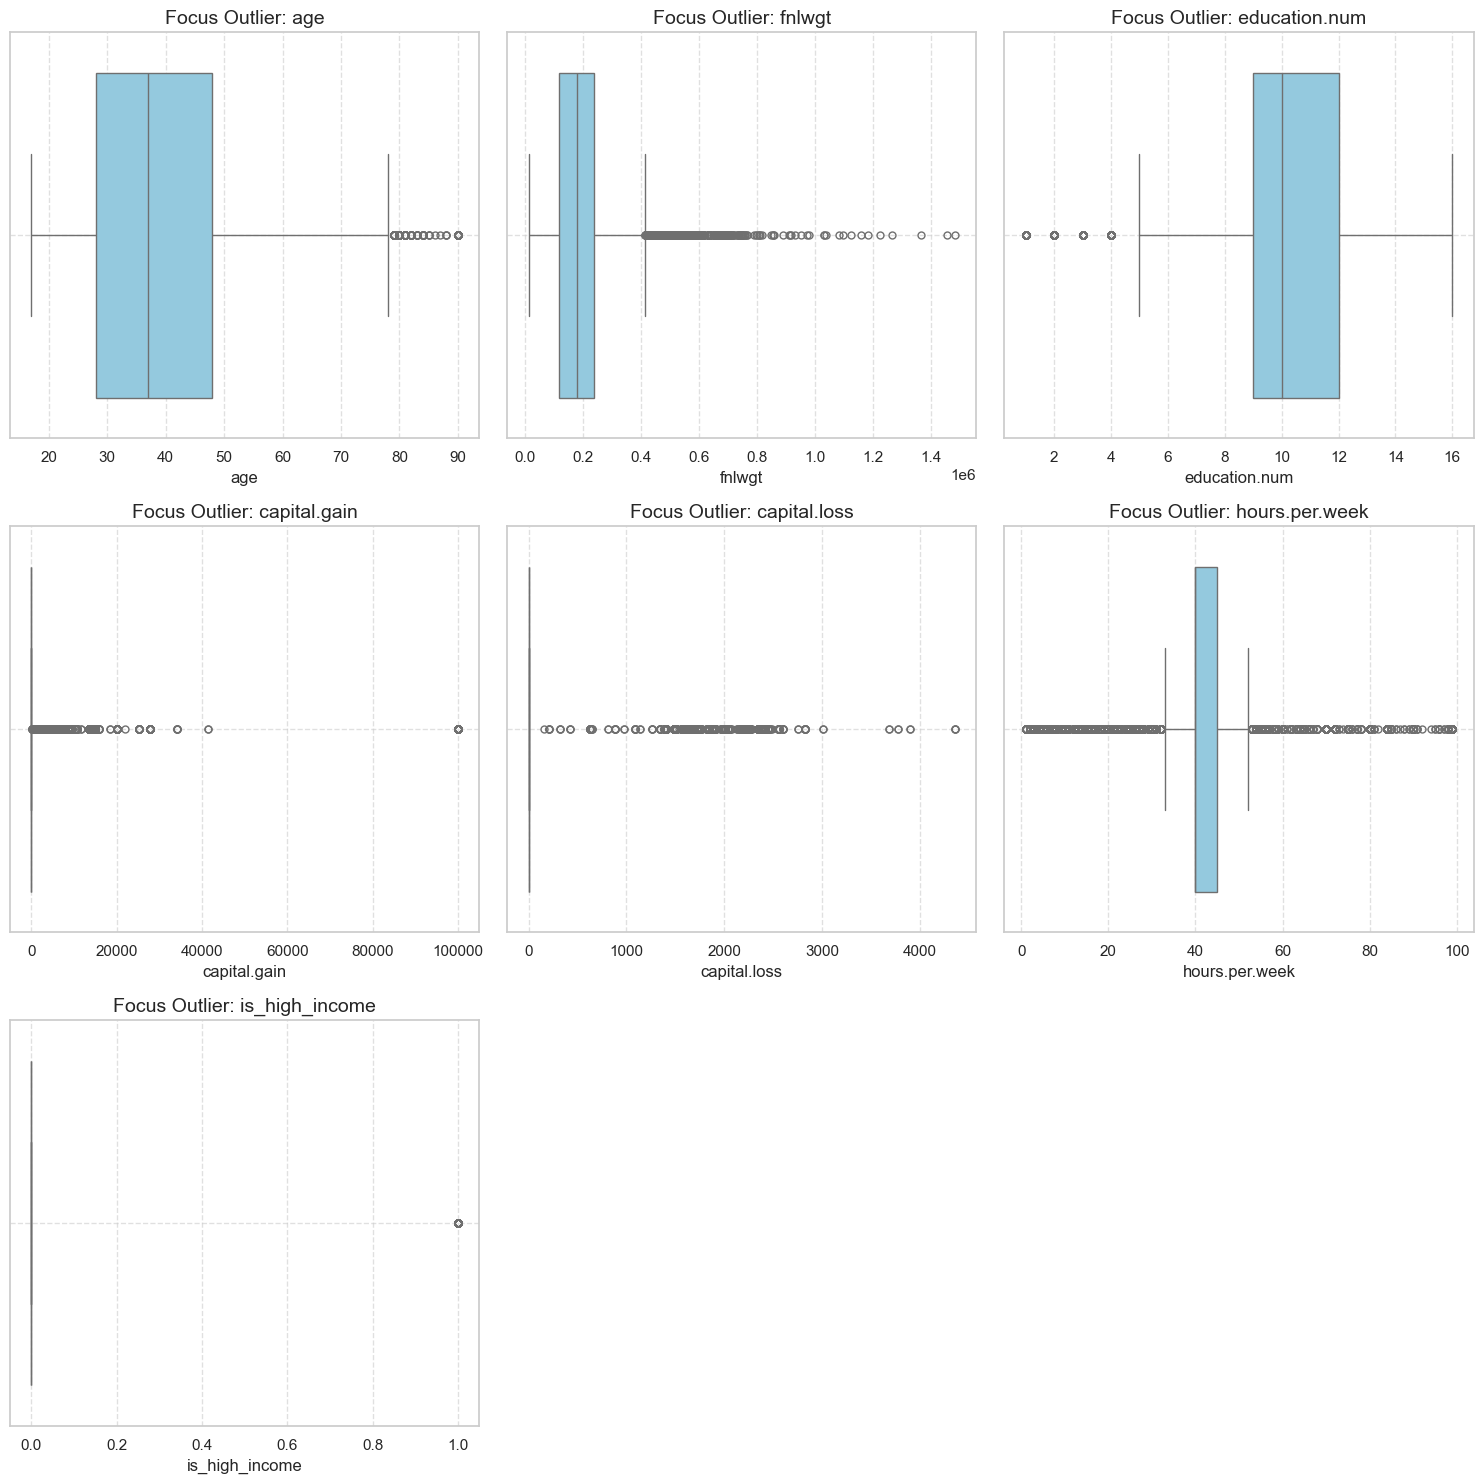

In [33]:
plot_outliers(df_1, result[0])

## Correlazione di Spearman

In [34]:
result[0]

['age',
 'fnlwgt',
 'education.num',
 'capital.gain',
 'capital.loss',
 'hours.per.week',
 'is_high_income']

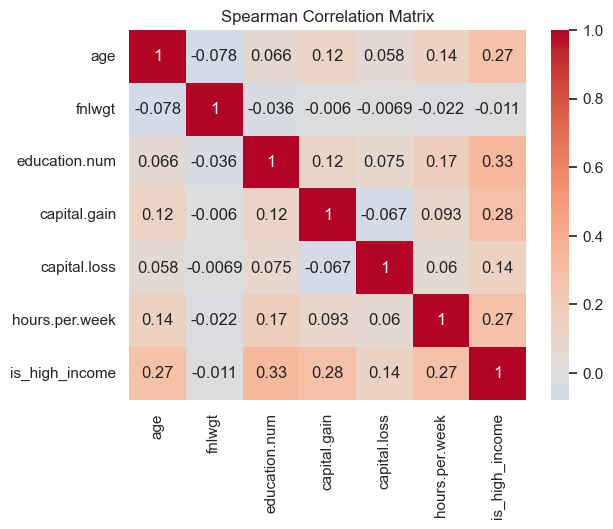

In [35]:
corr_spearman=df_1[result[0]].corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0)
plt.title('Spearman Correlation Matrix')
plt.show()

## Tabelle di contingenza

In [37]:
result[1]

['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country',
 'income',
 'age_bins']

In [38]:
# Creiamo la tabella di contingenza grezza
contingency_table = pd.crosstab(df_1['race'], df_1['is_high_income'])

print("Tabella di Contingenza (Frequenze Assolute):")
print(contingency_table)

Tabella di Contingenza (Frequenze Assolute):
is_high_income          0     1
race                           
Amer-Indian-Eskimo    275    36
Asian-Pac-Islander    763   276
Black                2737   387
Other                 246    25
White               20699  7117


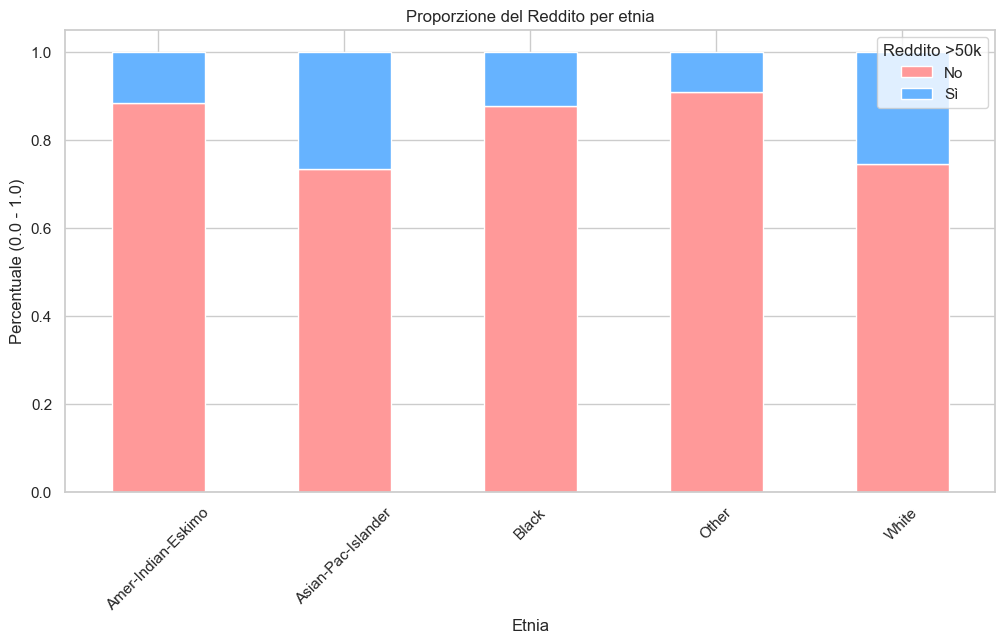

In [41]:
#trasformo in frequenze relative
# Normalizziamo per riga (ogni riga somma a 1.0, ovvero 100%)
ct_normalized = pd.crosstab(df_1['race'], df_1['is_high_income'], normalize='index')

# Creiamo lo Stacked Bar Chart
ct_normalized.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999', '#66b3ff'])
plt.title("Proporzione del Reddito per etnia")
plt.ylabel("Percentuale (0.0 - 1.0)")
plt.xlabel("Etnia")
plt.legend(title="Reddito >50k", labels=["No", "Sì"])
plt.xticks(rotation=45)
plt.show()

In [40]:
# check statiscal significance with chi2 test
from scipy.stats import chi2_contingency

# Eseguiamo il test sulla tabella dei FATTI (quella non normalizzata dello Step 1)
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Statistica Chi-Quadro: {chi2:.2f}")
print(f"P-Value: {p:.4e}") # Notazione scientifica perché sarà molto piccolo

Statistica Chi-Quadro: 330.92
P-Value: 2.3060e-70


In [42]:
# cramer's V
n = contingency_table.sum().sum() # Totale campioni
min_dim = min(contingency_table.shape) - 1 # Minimo tra (righe-1) e (colonne-1)
v_cramer = np.sqrt(chi2 / (n * min_dim))

print(f"V di Cramer: {v_cramer:.4f}")

V di Cramer: 0.1008


In [43]:


def analyze_all_categorical(df, cat_columns, target_col):
    results = []

    for col in cat_columns:
        # 1. Tabella di contingenza
        ct = pd.crosstab(df[col], df[target_col])
        
        # 2. Test Chi-Quadro
        chi2, p, dof, expected = chi2_contingency(ct)
        
        # 3. Calcolo V di Cramer
        n = ct.sum().sum()
        min_dim = min(ct.shape) - 1
        v_cramer = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
        
        # Salviamo i risultati in un dizionario
        results.append({
            'Variabile': col,
            'Chi-Quadro': round(chi2, 2),
            'P-Value': f"{p:.4e}",
            'V di Cramer': round(v_cramer, 4),
            'Significativo': "Sì" if p < 0.05 else "No"
        })

    # Creiamo il DataFrame finale e ordiniamo per V di Cramer (più alta = più importante)
    summary_df = pd.DataFrame(results).sort_values(by='V di Cramer', ascending=False)
    return summary_df



In [45]:
# Esecuzione
tabella_risultati_cat = analyze_all_categorical(df_1, result[1], 'is_high_income')
display(tabella_risultati_cat)

,Variabile,Chi-Quadro,P-Value,V di Cramer,Significativo
8,income,32555.53,0.0000e+00,0.9999,Sì
4,relationship,6699.08,0.0000e+00,0.4536,Sì
2,marital.status,6517.74,0.0000e+00,0.4474,Sì
1,education,4429.65,0.0000e+00,0.3688,Sì
3,occupation,3744.90,0.0000e+00,0.3492,Sì
9,age_bins,3217.53,0.0000e+00,0.3143,Sì
6,sex,1517.81,0.0000e+00,0.2159,Sì
0,workclass,827.72,1.9338e-174,0.1641,Sì
5,race,330.92,2.3060e-70,0.1008,Sì
7,native.country,317.09,8.2804e-45,0.0996,Sì


In [51]:
# Creiamo la tabella di contingenza grezza
con_marital_age = pd.crosstab(df_1['marital.status'], df_1['age_bins'])
print(f"Tabella di contingenza:\n {con_marital_age}")

Tabella di contingenza:
 age_bins               0-25  26-35  36-45  46-55  56-65  66+
marital.status                                              
Divorced                129    988   1630   1126    471   99
Married-AF-spouse         4     14      3      1      0    1
Married-civ-spouse      675   3759   4580   3459   1862  641
Married-spouse-absent    48    115    110     96     34   15
Never-married          5456   3290   1241    441    175   80
Separated                95    313    338    196     69   14
Widowed                   4     35    107    219    320  308


In [54]:
#trasformo in frequenze relative
# Normalizziamo per riga (ogni riga somma a 1.0, ovvero 100%)
ct_norm_marital_age = pd.crosstab(df_1['marital.status'], df_1['age_bins'], normalize='index')
ct_norm_marital_age

age_bins,0-25,26-35,36-45,46-55,56-65,66+
marital.status,,,,,,
Divorced,0.029034,0.222372,0.366869,0.253432,0.106009,0.022282
Married-AF-spouse,0.173913,0.608696,0.130435,0.043478,0.000000,0.043478
Married-civ-spouse,0.045072,0.251002,0.305823,0.230970,0.124332,0.042802
Married-spouse-absent,0.114833,0.275120,0.263158,0.229665,0.081340,0.035885
Never-married,0.510718,0.307966,0.116166,0.041281,0.016381,0.007489
Separated,0.092683,0.305366,0.329756,0.191220,0.067317,0.013659
Widowed,0.004028,0.035247,0.107754,0.220544,0.322256,0.310171


<Axes: xlabel='marital.status'>

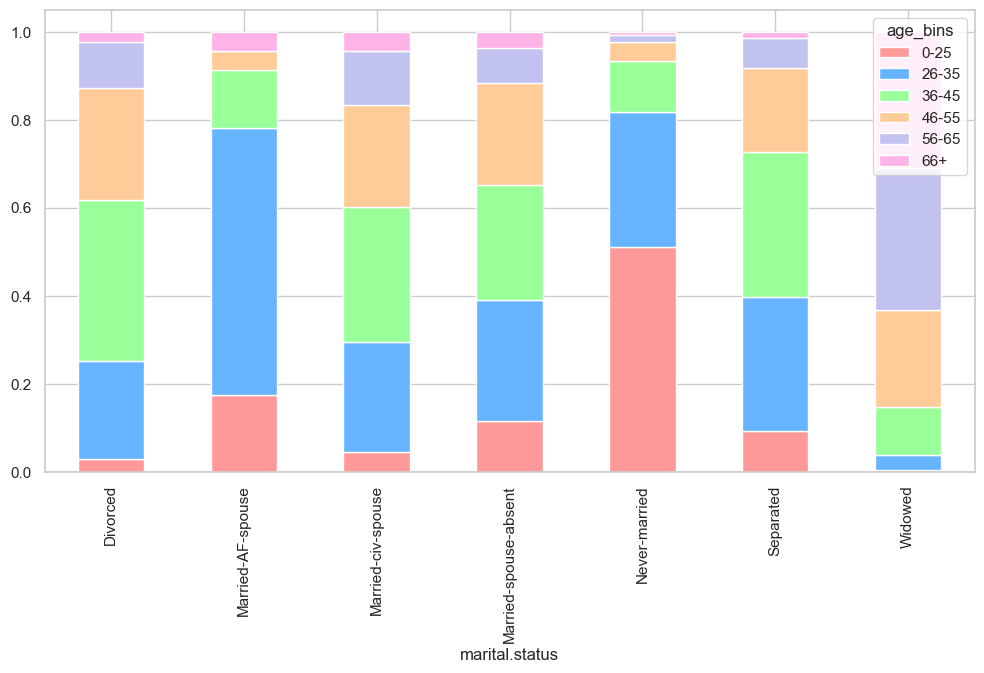

In [55]:
ct_norm_marital_age.plot(kind='bar',stacked=True, figsize=(12, 6), color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6'])

In [61]:

chi2, p, dof, expected = chi2_contingency(con_marital_age)
print(f"Statistica Chi-Quadro: {chi2:.2f}")
print(f"P-Value: {p:.4e}")
print(f"grado di libertà: {dof}")

Statistica Chi-Quadro: 15080.61
P-Value: 0.0000e+00
grado di libertà: 30


In [59]:
# cramer's V
n = con_marital_age.sum().sum() # Totale campioni
n

np.int64(32561)

In [60]:
min_dim = min(con_marital_age.shape) - 1 # Minimo tra (righe-1) e (colonne-1)
v_cramer = np.sqrt(chi2 / (n * min_dim))

print(f"V di Cramer: {v_cramer:.4f}")

V di Cramer: 0.3044


Il collegamento con la tua EDA
Il ColumnTransformer è dove metti in pratica i tuoi risultati:

Hai visto V di Cramer 0.30 tra marital-status e age? Ecco perché nel codice sopra le ho tenute entrambe.

Hai visto che capital-gain è schiacciato nei boxplot? Usi RobustScaler invece di StandardScaler.

Hai visto che income ha V di Cramer 0.99? Lo lasci fuori dal trasformatore (o usi remainder='drop').

# PIPELINE

In [81]:
df_1.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income', 'age_bins', 'is_high_income'],
      dtype='str')

In [83]:
# Identifichiamo i paesi rari (meno di 100 occorrenze)
counts = df_1['native.country'].value_counts()
rare_countries = counts[counts < 100].index
rare_countries

Index(['Cuba', 'England', 'Jamaica', 'South', 'China', 'Italy',
       'Dominican-Republic', 'Vietnam', 'Guatemala', 'Japan', 'Poland',
       'Columbia', 'Taiwan', 'Haiti', 'Iran', 'Portugal', 'Nicaragua', 'Peru',
       'Greece', 'France', 'Ecuador', 'Ireland', 'Hong', 'Trinadad&Tobago',
       'Cambodia', 'Laos', 'Thailand', 'Yugoslavia',
       'Outlying-US(Guam-USVI-etc)', 'Honduras', 'Hungary', 'Scotland',
       'Holand-Netherlands'],
      dtype='str', name='native.country')

In [84]:
# Li sostituiamo con 'Other'
df_1['native.country'] = df_1['native.country'].replace(rare_countries, 'Other')

## Preparazione: Divisione X e y
target separation

In [85]:
X=df_1.drop(columns=['income', 'is_high_income'])
y=df_1['is_high_income']

In [86]:
from sklearn.model_selection import train_test_split

In [87]:
# Dividiamo subito in Train e Test (fondamentale per evitare Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Definizione del ColumnTransformer
Qui applichiamo la "mappa" delle analisi: RobustScaler per gli outlier e OneHotEncoder per le categoriche.

In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline

In [90]:
#identificazione colonne numeriche e categoriche
num_features=[x for x in result[0] if x not in ['is_high_income', 'fnlwgt']]
num_features

['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

In [91]:
result[1]

['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country',
 'income',
 'age_bins']

In [92]:
cat_features=[x for x in result[1] if x not in ['income','age_bins']]
cat_features

['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country']

In [93]:
# Creiamo il preprocessore
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

## La Pipeline Completa (Preprocessing + Modello)
Invece di trasformare i dati e poi allenare il modello separatamente, mettiamo tutto in un unico oggetto. Per iniziare, usiamo un Random Forest, che gestisce bene le relazioni che abbiamo visto tra età e stato civile.

In [94]:
from sklearn.ensemble import RandomForestClassifier

# Creiamo la pipeline finale
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Alleniamo tutto il blocco in una riga sola!
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [95]:
from sklearn.metrics import classification_report

y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      4945
           1       0.68      0.63      0.65      1568

    accuracy                           0.84      6513
   macro avg       0.78      0.77      0.77      6513
weighted avg       0.83      0.84      0.84      6513

